In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [3]:
data = pd.read_csv("BankNote_Authentication.csv") 
# columns: variance, skewness, curtosis, entropy, class

print(data.head())
print(data.shape)


   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0
(1372, 5)


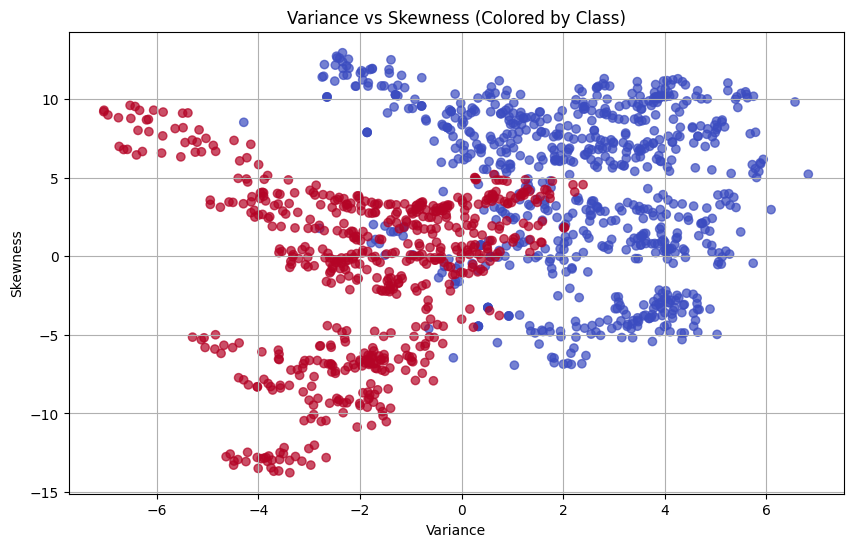

In [4]:
plt.figure(figsize=(10,6))
plt.scatter(data["variance"], data["skewness"], 
            c=data["class"], cmap='coolwarm', alpha=0.7)
plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Variance vs Skewness (Colored by Class)")
plt.grid(True)
plt.show()


In [5]:
X = data.drop(columns=["class"]).values
y = data["class"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1097, 4)
Test shape: (275, 4)


In [6]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


In [9]:
clf_no_l2 = LogisticRegression(
    solver='lbfgs', max_iter=2000
)
clf_no_l2.fit(X_train_s, y_train)

train_acc_no_l2 = clf_no_l2.score(X_train_s, y_train)
test_acc_no_l2 = clf_no_l2.score(X_test_s, y_test)

print("Train Accuracy (No L2):", train_acc_no_l2)
print("Test Accuracy (No L2):", test_acc_no_l2)


Train Accuracy (No L2): 0.9845031905195989
Test Accuracy (No L2): 0.9709090909090909


In [10]:
lambda_vals = [0.01, 0.1, 1, 10, 100]
train_acc_list = []
test_acc_list = []

for lam in lambda_vals:
    C = 1 / lam
    
    clf = LogisticRegression(
        penalty='l2', C=C, solver='lbfgs', max_iter=2000
    )
    clf.fit(X_train_s, y_train)
    
    train_acc_list.append(clf.score(X_train_s, y_train))
    test_acc_list.append(clf.score(X_test_s, y_test))


In [11]:
print("Lambda | Train Acc | Test Acc")
for lam, tr, te in zip(lambda_vals, train_acc_list, test_acc_list):
    print(lam, tr, te)


Lambda | Train Acc | Test Acc
0.01 0.9908842297174111 0.9854545454545455
0.1 0.9927073837739289 0.9854545454545455
1 0.9845031905195989 0.9709090909090909
10 0.9772105742935278 0.9709090909090909
100 0.9434822242479489 0.9381818181818182


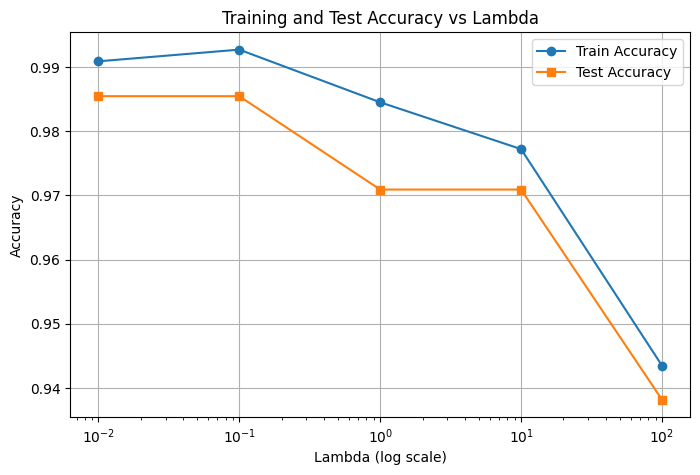

In [12]:
plt.figure(figsize=(8,5))
plt.plot(lambda_vals, train_acc_list, marker='o', label="Train Accuracy")
plt.plot(lambda_vals, test_acc_list, marker='s', label="Test Accuracy")

plt.xscale("log")
plt.xlabel("Lambda (log scale)")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy vs Lambda")
plt.grid(True)
plt.legend()
plt.show()


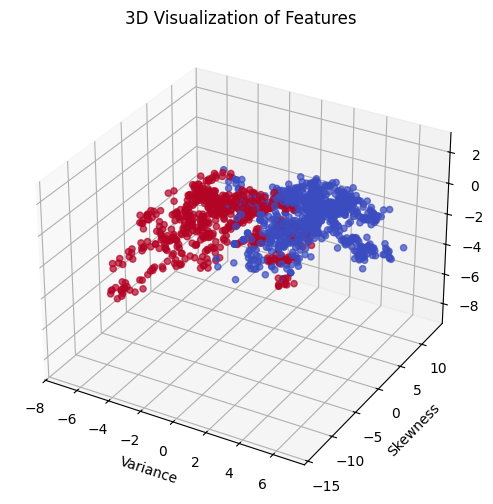

In [13]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    data["variance"], 
    data["skewness"], 
    data["entropy"],
    c=data["class"], cmap='coolwarm', alpha=0.7
)

ax.set_xlabel("Variance")
ax.set_ylabel("Skewness")
ax.set_zlabel("Entropy")
ax.set_title("3D Visualization of Features")
plt.show()


In [14]:
X_outlier = X.copy()
num_outliers = int(0.05 * len(X_outlier))

indices = np.random.choice(len(X_outlier), num_outliers, replace=False)
X_outlier[indices] += np.random.normal(20, 10, size=X_outlier[indices].shape)

print("Injected outliers at indices:", indices)


Injected outliers at indices: [ 216  261   69 1030  519 1333  634 1226  332  570  685  890  752  256
 1119  573 1321 1081 1052  285  748  706  218 1121  363 1264  897 1128
  714  372 1037  924  132  896  690 1314  283 1017  583  697   18  265
  914  996  611  755 1277   40  810 1142  715  512 1267 1262  763 1000
   79  500 1359  359  885 1003  452  971  793  817  783 1348]


In [16]:
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(X_outlier, y, test_size=0.2, random_state=42, stratify=y)

X_train_o_s = scaler.fit_transform(X_train_o)
X_test_o_s = scaler.transform(X_test_o)

clf_outlier = LogisticRegression(penalty='l2', C=1, max_iter=2000)
clf_outlier.fit(X_train_o_s, y_train_o)

train_acc_o = clf_outlier.score(X_train_o_s, y_train_o)
test_acc_o = clf_outlier.score(X_test_o_s, y_test_o)

print("Train Acc (Outlier):", train_acc_o)
print("Test Acc (Outlier):", test_acc_o)


Train Acc (Outlier): 0.8605287146763901
Test Acc (Outlier): 0.8472727272727273


In [17]:
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_curve, 
    roc_auc_score, 
    precision_score,
    recall_score,
    f1_score
)
import seaborn as sns


In [18]:
clf_final = LogisticRegression(
    penalty='l2', C=1, solver='lbfgs', max_iter=2000
)
clf_final.fit(X_train_s, y_train)

y_pred = clf_final.predict(X_test_s)
y_prob = clf_final.predict_proba(X_test_s)[:, 1]   # probabilities for class=1


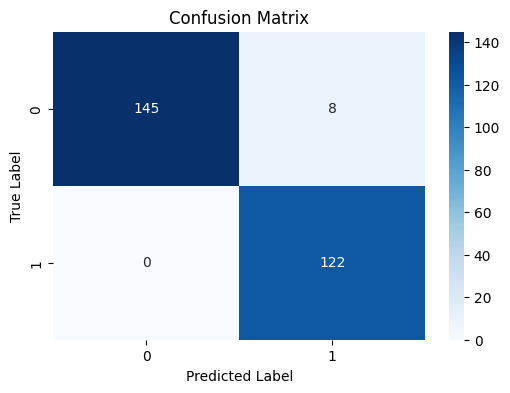

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [20]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)


Accuracy : 0.9709090909090909
Precision: 0.9384615384615385
Recall   : 1.0
F1 Score : 0.9682539682539683


In [21]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.95      0.97       153
           1       0.94      1.00      0.97       122

    accuracy                           0.97       275
   macro avg       0.97      0.97      0.97       275
weighted avg       0.97      0.97      0.97       275



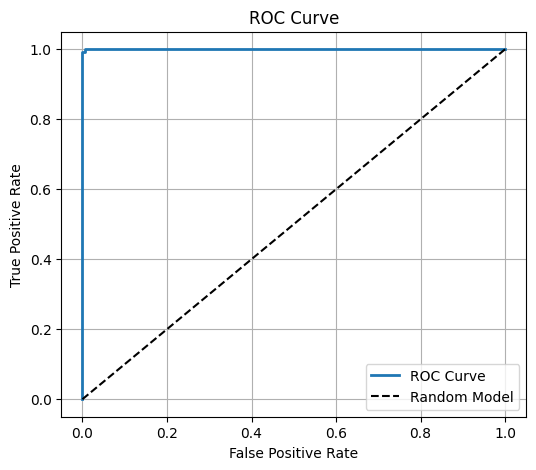

AUC Score: 0.9999464266580949


In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2, label="ROC Curve")
plt.plot([0, 1], [0, 1], 'k--', label="Random Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)


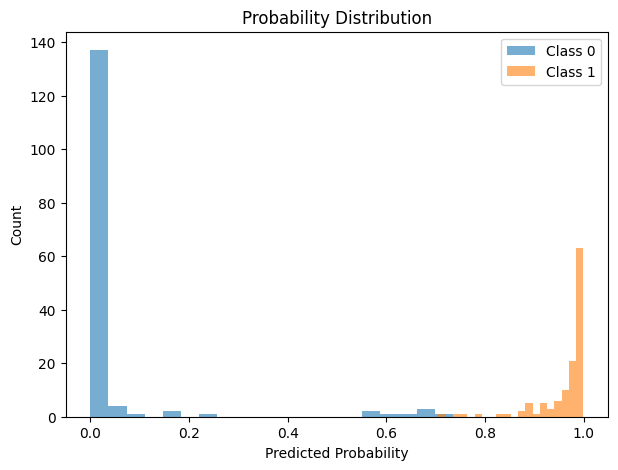

      Metric     Value
0   Accuracy  0.970909
1  Precision  0.938462
2     Recall  1.000000
3   F1 Score  0.968254
4        AUC  0.999946


In [24]:
plt.figure(figsize=(7,5))
plt.hist(y_prob[y_test==0], bins=20, alpha=0.6, label="Class 0")
plt.hist(y_prob[y_test==1], bins=20, alpha=0.6, label="Class 1")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Probability Distribution")
plt.legend()
plt.show()

metric_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"],
    "Value": [acc, prec, rec, f1, auc_score]
})
print(metric_table)

